# Examen Módulo 2 - Montecarlo.

---


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd

### Simulación Montecarlo usando Caminata aleatoria<font size='1'>(3.4 puntos)</font>

Se desea conocer el estado final de un proceso hipotético definido como una Máquina de estados. Este proceso cuenta con los estados: **A**, **B** y **C**. El proceso se define de la siguiente manera:

- Estando en el estado **A**, 2 de cada 3 operaciones cambia al estado **B**, el resto de casos cambia al estado **C**.
- Estando en el estado **B**, 3 de cada 5 operaciones cambia al estado **A**, el resto de casos se mantiene en el estado **B**.
- Estando en el estado **C**, 4 de cada 5 operaciones cambia al estado **A**, el resto de casos se mantiene en el estado **C**.

Respresentado por el siguiente diagrama


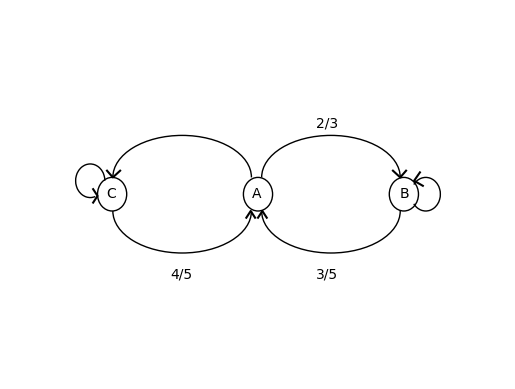

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

A = patches.Circle((0, 0), 0.1, fc="None", color="k")
B = patches.Circle((1, 0), 0.1, fc="None", color="k")
C = patches.Circle((-1, 0), 0.1, fc="None", color="k")
AB = patches.Arc((0.5, 0.1), 0.95, 0.5, theta2=180, fc="None", color="k")
BA = patches.Arc((0.5, -0.1), 0.95, 0.5, theta1=180, fc="None", color="k")
AC = patches.Arc((-0.52, 0.1), 0.95, 0.5, theta2=180, fc="None", color="k")
CA = patches.Arc((-0.52, -0.1), 0.95, 0.5, theta1=180, fc="None", color="k")
CC = patches.Arc((-1.15, 0.08), 0.2, 0.2, theta2=290, fc="None", color="k")
BB = patches.Arc((1.15, 0), 0.2, 0.2, theta1=-145, theta2=145, fc="None", color="k")
ax = plt.gca()
ax.add_artist(A)
ax.add_artist(B)
ax.add_artist(C)
ax.add_artist(AB)
ax.add_artist(BA)
ax.add_artist(AC)
ax.add_artist(CA)
ax.add_artist(BB)
ax.add_artist(CC)

plt.plot([0.925, 0.975, 1.015], [0.14, 0.1, 0.14], "k")  # AB
plt.plot([0.06, 0.03, 0], [-0.14, -0.1, -0.14], "k")  # BA
plt.plot([-0.945, -0.995, -1.035], [0.14, 0.1, 0.14], "k")  # AC
plt.plot([-0.02, -0.05, -0.08], [-0.14, -0.1, -0.14], "k")  # CA
plt.plot([1.13, 1.07, 1.11], [0.05, 0.08, 0.13], "k")  # BB
plt.plot([-1.13, -1.1, -1.13], [0.03, -0.01, -0.05], "k")  # CC

plt.text(-0.04, -0.02, "A")
plt.text(0.97, -0.02, "B")
plt.text(-1.04, -0.02, "C")
plt.text(0.4, 0.4, "2/3")  # AB
plt.text(0.4, -0.5, "3/5")  # BA
plt.text(-0.6, -0.5, "4/5")  # CA

plt.axis([-1.7, 1.7, -1.1, 1.1])
plt.axis("off")
plt.show()

1. Defina una función que permita simular el proceso antes descrito.


In [4]:
def MaquinaEstados(estadoInicial):
    if estadoInicial == "A":
        return np.random.choice(["B", "C"], p=[2 / 3, 1 / 3])
    elif estadoInicial == "B":
        return np.random.choice(["A", "B"], p=[3 / 5, 2 / 5])
    elif estadoInicial == "C":
        return np.random.choice(["A", "C"], p=[4 / 5, 1 / 5])

2. Si el proceso parte del estado **A**, y se ejecutan 100 operaciones. Usando el método Montecarlo con 10000 escenarios, ¿Cuál es la probabilidad de que el proceso finalice en el estado **B**?.


In [19]:
escenarios = 10000
estadoFinal = []
for i in range(escenarios):
    estado = "A"
    operaciones = 100
    for j in range(operaciones):
        estado = MaquinaEstados(estado)
    estadoFinal.append(estado)

datosFiltrados = [i for i in estadoFinal if i == "B"]
probabilidad = len(datosFiltrados) / escenarios
print(
    f"La probabilidad de que el sistema se encuentre en el estado B después de 100 operaciones es de {probabilidad}"
)

La probabilidad de que el sistema se encuentre en el estado B después de 100 operaciones es de 0.4328


---

### Simulación de escenarios futuros <font size='1'>(3.4 puntos)</font>

Suponga que desea invertir en **Spotify** o **Mercado Libre**. Evalúe la probabilidad de obtener un retorno del 5% en 15 días a partr del 6 de noviembre del presente año.


1. Obtenga los precios de cierre ajustados desde _YAHOO finance_ de Spotify y Mercado Libre desde el 5 de noviembre de 2020 al 5 de noviembre de 2024.


In [6]:
inicio = "2020-11-5"
final = "2024-11-5"

dataSpot = yf.download("SPOT", start=inicio, end=final)["Adj Close"]
dataMeli = yf.download("MELI", start=inicio, end=final)["Adj Close"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


2. Calcule el rendimiento para ambas empresas.


In [7]:
rendimientoSpot = dataSpot.pct_change().dropna()
rendimientoMeli = dataMeli.pct_change().dropna()

3. Calcule la media y desviación estandar de los rendimientos y simule 100000 escenarios de los rendimientos para los 15 días siguientes al 6 de noviembre.


In [8]:
nDias = 15
nSimulaciones = 100000
fechas = pd.date_range("2024-11-6", periods=15)

rendimientoSpotSimulado = pd.DataFrame(
    np.random.normal(
        rendimientoSpot.mean(), rendimientoSpot.std(), size=(nDias, nSimulaciones)
    ),
    fechas,
)

rendimientoMeliSimulado = pd.DataFrame(
    np.random.normal(
        rendimientoMeli.mean(), rendimientoMeli.std(), size=(nDias, nSimulaciones)
    ),
    fechas,
)

4. Use los datos de simulación para obtener los precios proyectados al cierre para ambas empresas.


In [9]:
rendimientoSpotFiltrado = (
    dataSpot.iloc[-1, 0] * (rendimientoSpotSimulado + 1).cumprod(axis=0)
    > dataSpot.iloc[-1, 0] * 1.05
).mean(axis=1)

rendimientoMeliFiltrado = (
    dataMeli.iloc[-1, 0] * (rendimientoMeliSimulado + 1).cumprod(axis=0)
    > dataMeli.iloc[-1, 0] * 1.05
).mean(axis=1)

5. En un gráfico muestre la evolución de ambas probabilidades de obtener un retorno del 5% en 15 días a partir de la fecha indicada. ¿Cuál genera mayores espectativas?


Probabilidad de que el precio de la acción de Spotify suba un 5% en 15 días


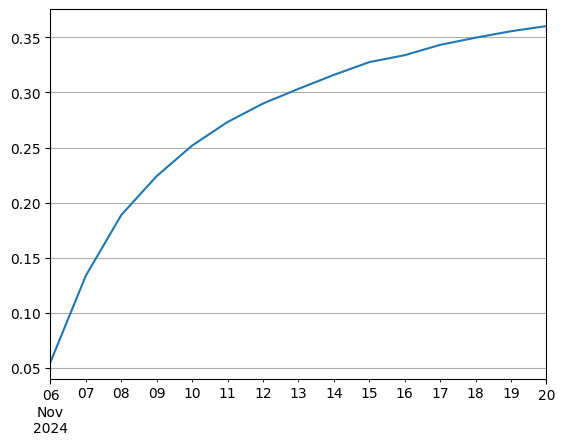

Probabilidad de que el precio de la acción de Mercado Libre suba un 5% en 15 días


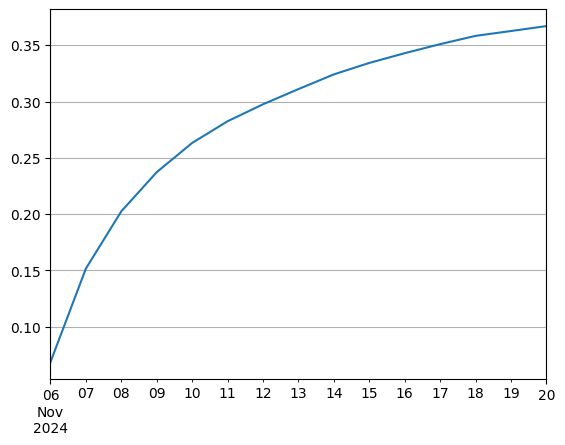

In [10]:
rendimientoSpotFiltrado.plot(grid=True)
print("Probabilidad de que el precio de la acción de Spotify suba un 5% en 15 días")
plt.show()

rendimientoMeliFiltrado.plot(grid=True)
print(
    "Probabilidad de que el precio de la acción de Mercado Libre suba un 5% en 15 días"
)
plt.show()

---

### Simulación de modelos deterministas <font size='1'>(3.6 puntos)</font>

Se desea enfriar agua con diferentes concentraciones de minerales cuya constante de enfriamiento $(k)$ varía de $-0.015s^{-1}$ a $-0.15s^{-1}$. La temperatura del entorno $(T_A)$ puede enfriarse de 25°C a -15°C, mas el costo por hacerlo se aproxima a $C_{enfriado}(T_A)=12(T_A-25)^2$. Además, el tiempo por enfriar la mezcla de agua es vital, por lo que demorarse en hacerlo ocaciona pérdidas que se aproximan como $C_{demora}(t)=(0.5t)^3$.

Encuentre el costo óptimo de enfriar las diferentes mezclas a 25°C usando 10000 escenarios con el modelo

$$
\frac{dT}{dt}=k(T-T_A),
$$

siendo la temperatura inicial de 60°C.


In [18]:
def enfriamiento(T0, TA, k, t):
    return T0 * np.exp(k * t) + TA * (1 - np.exp(k * t))


def costo_total(TA, t):
    C_enfriado = 12 * (TA - 25) ** 2
    C_demora = (0.5 * t) ** 3
    return C_enfriado + C_demora


T0 = 60
TA_values = np.random.uniform(-15, 25, 10000)
k_values = np.random.uniform(-0.15, -0.015, 10000)

costos = []
for TA, k in zip(TA_values, k_values):
    t = np.log((25 - TA) / (T0 - TA)) / k
    costos.append(costo_total(TA, t))

costo_optimo = min(costos)
print(f"Costo óptimo: {costo_optimo}")

Costo óptimo: 627.0586665636819
